In [1]:
!python --version

Python 3.13.15


# Count Bikes Notebook

I have trained a RF-DETR model on Roboflow using the 994 frames mined from the find candidates and upload notebooks. The model started off strong and didn't improve much. I'm curious if it performs any better than a pretrained RF-DETR or YOLO model. 

In this notebook I will build a detector-agnostic pipeline for counting bikes in my test clips. I used a tool I had Claude build for manually counting and logging bike crossings in the test clips to give me a ground truth to compare the model to. This structure will let me evaluate my trained model, a pretrained RF-DETR model, and YOLO models against ground truth and draw conclusions about their performance.

## Basic Steps:
 - config
 - load model
 - detection pass
 - cache detections to save time testing downstream counting
 - check detections and cache
 - track bikes
 - count bikes
 - export annotated video
 - compare results to ground truth
 - find mismatched counts / not-counts
 - review frames with missed or extra bikes
 - evaluate effect of framerate on counts to determine deployment floor

Ultimately, I hope to determine what mAP couldn't tell me, will the model accurately count bikes? I also want to answer the nagging question in my head, could I have just used pretrained RF-DETR or YOLO?

## Config

Everything tunable lives here. These two test clips were held out from training and hand-counted with `count_manual.py` which provides a ground truth for the pipeline, rather than just the detector.

The counting line is deliberately extended well past the frame edges - this is explained further in the LineZone section below.

In [3]:
import os
from pathlib import Path

from dotenv import load_dotenv
import supervision as sv

load_dotenv()

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.git').exists())

# 5pm rush hour clip
# ground_truth = ROOT / 'testclips' / 'clip_20260812_170115_manual_counts.csv'
# clip = ROOT / 'testclips' / 'clip_20260812_170115.h264'

# 2pm low traffic clip
clip = ROOT / 'testclips' / 'clip_20260812_140056.h264'
ground_truth = ROOT / 'testclips' / 'clip_20260812_140056_manual_counts.csv'

# from Roboflow web UI
model_id = 'alan-l-abbott-gmail-com/bikecounter-2-rfdetr-small-t1'
fps = 15.0
conf = 0.4 # roboflow determined optimal confidence was 36%, rounded up here

# from pick_line.py - line slants to match camera angle and catch bikes mid-frame
# line_start = sv.Point(1426,1080)
# line_end = sv.Point(920,0)

# extending line to fix SB missed counts
line_start = sv.Point(1600, 1450)
line_end   = sv.Point(800, -350)

cache = Path('cache')
cache.mkdir(exist_ok=True)

In [4]:
# warning suppression
os.environ['CORE_MODEL_GAZE_ENABLED'] = 'False'
os.environ['CORE_MODEL_SAM_ENABLED'] = 'False'
os.environ['CORE_MODEL_SAM3_ENABLED'] = 'False'

from inference import get_model

model = get_model(model_id=model_id, api_key=os.getenv('ROBOFLOW_API_KEY'))
print(f'loaded model: {model_id}')

[08/21/26 19:52:00] WARNING  Your inference package version 1.3.8 is out of date! Please upgrade to  ]8;id=5837218;file:///Users/alan/projects/bikecounter/.venv/lib/python3.13/site-packages/inference/core/__init__.py\__init__.py]8;;\:]8;id=5837219;file:///Users/alan/projects/bikecounter/.venv/lib/python3.13/site-packages/inference/core/__init__.py#50\50]8;;\
                             version 1.5.0 of inference for the latest features and bug fixes by                   
                             running `pip install --upgrade inference`.                                            

[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.
/Users/alan/projects/bikecounter/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


loaded model: alan-l-abbott-gmail-com/bikecounter-2-rfdetr-small-t1


2026-08-21 19:52:03.126418 [W:onnxruntime:, coreml_execution_provider.cc:112 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 103 number of nodes in the graph: 889 number of nodes supported by CoreML: 711


In [5]:
from contextlib import contextmanager

import cv2

@contextmanager
def video_capture(path):
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise SystemExit(f'could not open {path}')
    try:
        yield cap
    finally:
        cap.release()

## Detection, cached to disk

Detection is the slowest part of the pipeline currently, running at 4 fps on my M4 Macbook Air, so a 15 minute clip takes about an hour to run detections on. Changes to the rest of the pipeline are independent of the detections so caching lets me iterate on the counting line, the trackers, and other parameters without rerunning detections every time.

The per-frame detections are saved to a pickle containing the clip name and confidence so changing conf will trigger rerunning detections correctly.

Something I learned, is that while get_model() downloads weights and runs detection locally, Roboflow still meters self-hosted inference at 1 credit per 3,000 images. I could have read the pricing page before assuming self-hosted = free, but at least they're free trial credits. ¯\(ツ)/¯

In [6]:
import pickle

from tqdm.notebook import tqdm

cache_path = cache / f'{clip.stem}_conf{conf}_detections.pkl'

def run_detection(clip_path, conf):
    per_frame = []
    with video_capture(clip_path) as cap, tqdm(desc='detecting', unit='f') as pbar:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            result = model.infer(frame, confidence=conf)[0]
            det = sv.Detections.from_inference(result)
    
            per_frame.append({
                'xyxy': det.xyxy,
                'confidence': det.confidence,
                'class_id': det.class_id,
            })
            pbar.update(1)
    return per_frame

if cache_path.exists():
    with open(cache_path, 'rb') as f:
        detections_by_frame = pickle.load(f)
    print(f'loaded {len(detections_by_frame)} frames from cache')
else:
    detections_by_frame = run_detection(clip, conf)
    with open(cache_path, 'wb') as f:
        pickle.dump(detections_by_frame, f)
    print(f'detected and cached {len(detections_by_frame)} frames')

loaded 13496 frames from cache


## Check the cache

Quick sanity check before building the rest of the pipeline, confirms that detections ran, confidence wasn't set too high, results look reasonable.

In [7]:
import numpy as np

counts = [len(d['xyxy']) for d in detections_by_frame]
nonzero = sum(1 for c in counts if c > 0)

print(f'frames: {len(counts)}')
print(f'frames with >=1 detection: {nonzero} ({nonzero/len(counts):.1%})')
print(f'max detections in one frame: {max(counts)}')

confs = [d['confidence'] for d in detections_by_frame
         if d['confidence'] is not None and len(d['confidence'])]

if confs:
    all_conf = np.concatenate(confs)
    print(f'total detections: {len(all_conf)}')
    print(f'confidence: min {all_conf.min():.2f} '
          f'median {np.median(all_conf):.2f} max {all_conf.max():.2f}')
else:
    print('no detections at all - check the model and confidence threshold')

frames: 13496
frames with >=1 detection: 664 (4.9%)
max detections in one frame: 2
total detections: 699
confidence: min 0.40 median 0.87 max 0.95


## Track and Count

The pipeline is made of three pieces. The detector, above, identifies bicycles and where they are in the frame, giving class ID, bounding boxes, and confidence.

### Tracking - ByteTrack

The tracker (ByteTrack) gives each bicycle a consistent `tracker_id` by associating boxes in adjacent frames, using IoU overlap to establish consistent identity. This takes per-frame detections and gives each bicycle a track that can be used to counting.

One challenge I have observed is that bikes moving too quickly or detections running at too low of fps (simulated by changing stride) mean that ByteTrack doesn't have enough overlap to establish a consistent ID for a bicycle. I am planning to try the C-BIoU tracker which replaces plain IoU with Cascaded Buffered IoU, which expands the bounding boxes before tracking to establish ID more reliably for fast moving objects or at low frame rates.

### Counting - LineZone

The LineZone keeps track of which side of the line each bicycle `tracker_id` was on last frame and fires when a bike changes from one side to the other. It is entirely dependent on stable IDs, without tracking it can't compare frames to see a bike crossing the line.

In [8]:
from trackers import ByteTrackTracker

def track_and_count(detections_by_frame, start, end, stride=1, fps=fps,
                    min_iou=0.1, activation=0.7, lost_buffer=30):
    effective_fps = fps / stride
    tracker = ByteTrackTracker(
        frame_rate=effective_fps,
        minimum_iou_threshold=min_iou,
        track_activation_threshold=activation,
        lost_track_buffer=lost_buffer,
    )
    line_zone = sv.LineZone(start=start, end=end)

    events = []
    tracked_by_frame = {}

    for frame_idx, d in enumerate(detections_by_frame):
        if frame_idx % stride != 0:
            continue

        det = sv.Detections(
            xyxy=d['xyxy'],
            confidence=d['confidence'],
            class_id=d['class_id']
        )
        det = tracker.update(det)

        if det.tracker_id is not None:
            det = det[det.tracker_id != -1]

        crossed_in, crossed_out = line_zone.trigger(det)

        if len(det) > 0 and det.tracker_id is not None:
            for i, tid in enumerate(det.tracker_id):
                if crossed_in[i] or crossed_out[i]:
                    events.append({
                        'frame': frame_idx,
                        'seconds': round(frame_idx / fps, 2),
                        'direction': 'IN' if crossed_in[i] else 'OUT',
                        'tracker_id': int(tid),
                    })
                    
        tracked_by_frame[frame_idx] = det
    return events, tracked_by_frame, line_zone

events, tracked, line_zone = track_and_count(
    detections_by_frame, line_start, line_end, stride=1)

print(f'IN: {line_zone.in_count}')
print(f'OUT: {line_zone.out_count}')
print(f'total events: {len(events)}')

IN: 7
OUT: 4
total events: 11


/Users/alan/projects/bikecounter/.venv/lib/python3.13/site-packages/trackers/core/sort/tracker.py:26: FutureWarning: target=None is deprecated since `v0.8`; use `TargetMode.NOTIFY` instead. Will be removed in `v1.0`.
  @deprecated(target=None, deprecated_in="0.4", remove_in="1.0")


In [9]:
import pandas as pd

direction_map = {'IN': 'SB', 'OUT': 'NB'}

gt = pd.read_csv(ground_truth)
pred = pd.DataFrame(events)
if len(pred):
    pred['direction'] = pred['direction'].map(direction_map)

print('ground truth')
print(gt['direction'].value_counts().to_string())
print(f'  total {len(gt)}\n')

print('pipeline')
if len(pred):
    print(pred['direction'].value_counts().to_string())
    print(f'  total {len(pred)}')
else:
    print('  no events')

ground truth
direction
SB    9
NB    4
  total 13

pipeline
direction
SB    7
NB    4
  total 11


## Event Matching

Using `count_manual.py` to log events did double-duty giving not just counts but timestamps for each bicycle in my ground truth clips. Matching events ensures that totals don't mask double counts and missed bikes cancelling each other. This also makes diagnosing missed or extra bikes easier because I can jump to the relevant timestamp or frame number to visually confirm what the problem might be.

For example:
 - Southbound bikes occluded by large vehicles in the traffic lane
 - Bicycles veering out of frame on the sidewalk
 - Bikes on the bus rack - counted per policy but hard to detect

**Important:** This only helped with what I could see on the frame, notable exception explained below.

In [10]:
tolerance_s = 3.0

def match_events(gt_df, pred_df, tolerance=tolerance_s):
    pool = pred_df.to_dict('records') if len(pred_df) else []
    used = set()
    matched, missed = [], []

    for _, g in gt_df.iterrows():
        best, best_dt = None, None
        for j, p in enumerate(pool):
            if j in used or p['direction'] != g['direction']:
                continue
            dt = abs(p['seconds'] - g['seconds'])
            if dt <= tolerance and (best_dt is None or dt < best_dt):
                best, best_dt = j, dt
        if best is None:
            missed.append(g.to_dict())
        else:
            used.add(best)
            matched.append((g.to_dict(), pool[best], best_dt))

    extra = [p for j, p in enumerate(pool) if j not in used]
    return matched, missed, extra

matched, missed, extra = match_events(gt, pred)

print(f'matched: {len(matched)}')
print(f'missed: {len(missed)}  (in ground truth, pipeline did not count)')
print(f'extra: {len(extra)}  (pipeline counted, not in ground truth)')

if missed:
    print('\nMISSED')
    for m in missed:
        print(f"  {m['timestamp']}  {m['direction']}  frame {m['frame']}")

if extra:
    print('\nEXTRA')
    for e in extra:
        print(f"  {e['seconds']:>8.2f}s  {e['direction']}  "
              f"track #{e['tracker_id']}  frame {e['frame']}")

matched: 11
missed: 2  (in ground truth, pipeline did not count)
extra: 0  (pipeline counted, not in ground truth)

MISSED
  11:33.00  SB  frame 10395
  14:59.80  SB  frame 13497


In [11]:
@contextmanager
def video_writer(path, fps, size):
    writer = cv2.VideoWriter(str(path), cv2.VideoWriter_fourcc(*'mp4v'), fps, size)
    if not writer.isOpened():
        raise SystemExit(f'could not open writer for {path}')
    try:
        yield writer
    finally:
        writer.release()

In [12]:
def export_annotated(clip_path, tracked_by_frame, start, end, out_path,
                     stride=1, fps=fps):
    box_ann = sv.BoxAnnotator(thickness=2)
    label_ann = sv.LabelAnnotator(text_scale=0.5)
    trace_ann = sv.TraceAnnotator(trace_length=30)
    line_ann = sv.LineZoneAnnotator(thickness=2, text_scale=0.8)

    # fresh zone so the on-screen totals advance as the video plays
    zone = sv.LineZone(start=start, end=end)

    # first pass just to get frame dimension
    with video_capture(clip_path) as cap:
        ok, probe = cap.read()
        if not ok:
            raise SystemExit('could not read frames')
        h, w = probe.shape[:2]

    effective_fps = max(1, int(fps / stride))
    idx = -1

    with video_capture(clip_path) as cap, \
         video_writer(out_path, effective_fps, (w, h)) as writer, \
         tqdm(desc='writing', unit='f') as pbar:

        while True:
            ok, frame = cap.read()
            if not ok:
                break
            idx += 1
            if idx not in tracked_by_frame:
                continue

            det = tracked_by_frame[idx]
            zone.trigger(det)
    
            out = frame.copy()
            if len(det) > 0:
                out = trace_ann.annotate(scene=out, detections=det)
                out = box_ann.annotate(scene=out, detections=det)
                if det.tracker_id is not None and det.confidence is not None:
                    labels = [f'#{t} {c:.2f}'
                              for t, c in zip(det.tracker_id, det.confidence)]
                    out = label_ann.annotate(scene=out, detections=det,
                                             labels=labels)
            out = line_ann.annotate(frame=out, line_counter=zone)
            writer.write(out)
            pbar.update(1)
    print(f'wrote {out_path}')

# temporarily disable writing annotated video - the slowest part after detections
# out_video = Path(f'{clip.stem}_annotated.mp4')
# export_annotated(clip, tracked, line_start, line_end, out_video)

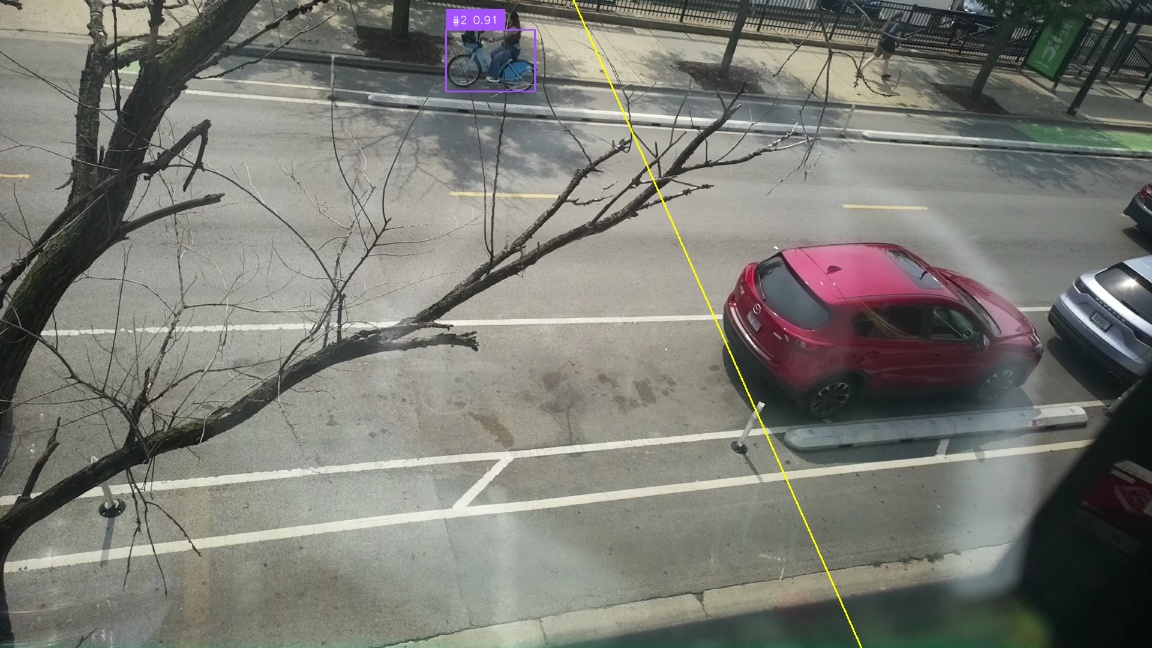

In [13]:
from IPython.display import Image, display

def show_frame(clip_path, frame_number, tracked_by_frame, scale=0.6):
    with video_capture(clip_path) as cap:
        frame = None
        for _ in range(frame_number+1):
            ok, frame = cap.read()
            if not ok:
                break
    if frame is None:
        print('could not reach that frame')
        return

    det = tracked_by_frame.get(frame_number)
    out = frame.copy()

    if det is not None and len(det) > 0:
        out = sv.BoxAnnotator(thickness=2).annotate(scene=out, detections=det)
        if det.tracker_id is not None and det.confidence is not None:
            labels = [f'#{t} {c:.2f}'
                      for t, c in zip(det.tracker_id, det.confidence)]
            out = sv.LabelAnnotator(text_scale=0.6).annotate(
                scene=out, detections=det, labels=labels)

    cv2.line(out, (line_start.x, line_start.y),
             (line_end.x, line_end.y), (0, 255, 255), 2)

    out = cv2.resize(out, None, fx=scale, fy=scale)
    _, buf = cv2.imencode('.jpg', out)
    display(Image(data=buf.tobytes()))

# missed bike - clearly tracked, yet not counted
missed_bike_frame = (6*60+40)*15
show_frame(clip, missed_bike_frame, tracked)

## How low can you go? In FPS, that is

Given my ultimate goal is to deploy this to an Raspberry Pi 4, I want to know how many frames per second I need to achieve in deployment. By adjusting stride, I can lower my effective FPS to understand where counts start to suffer due to lost tracks or missed bikes altogether.

Based on these results, for both 2pm and 5pm traffic, counts remained accurate at 7.5 fps, slightly deteriorated at 5 fps, and completely fell off at 3 fps. I would like to explore using the C-BIoU tracker to see if expanding bounding boxes before tracking yields better results. However, given I was only able to run at ~4 fps before thermal throttling on my M4 Macbook Air, I'd say it's not looking good for the Pi. I would like to try using a spare M720q I have from my homelab cluster and see if I can use OpenVINO to get a decent framerate for detections. If that fails then I would be looking at repurposing my GTX 1060 or purchasing a Pi5 and AI Hat.

In [14]:
rows = []
for stride in [1, 2, 3, 5]:
    _, _, lz = track_and_count(detections_by_frame, 
                                line_start, line_end, stride=stride)
    rows.append({
        'stride': stride,
        'effective_fps': round(fps / stride, 1),
        'IN': lz.in_count,
        'OUT': lz.out_count,
        'total': lz.in_count + lz.out_count,
    })

sweep = pd.DataFrame(rows)
print(f'ground truth: {len(gt)} total '
      f'({(gt.direction == "NB").sum()} NB, {(gt.direction == "SB").sum()} SB)')
sweep

ground truth: 13 total (4 NB, 9 SB)


,stride,effective_fps,IN,OUT,total
0,1,15.0,7,4,11
1,2,7.5,7,4,11
2,3,5.0,6,4,10
3,5,3.0,2,0,2


## Why LineZone extends past the frame

Several southbound bikes were detected with high confidence, consistent tracked IDs, and clearly cross the line rendered on the frame, but the counter wasn't incrementing. I felt insane as I watched annotated bikes with good tracks cross my line and nothing happen.

Checking the supervision source yielded the answer. `LineZone` doesn't just look at which side of the line a box is on. It first checks whether the box is in within a *region of interest* which consists of the band between two lines extending perpendicular from the end of the counting line. It's less of a counting 'line' and more of a counting rectangle.

The `LineZone` counter requires every anchor of the box to be inside that rectangular region of interest. Because my line is slanted to match the camera angle and catch both southbound and northbound bikes roughly mid-frame, the rectangle extending from the line to the left misses the upper anchors of some southbound bike boxes.

The diagnostic cells below show the pattern of tracked bikes showing right of the line, straddling the line, then moving out of limites before appearing left of the line. This causes the counting to be skipped and the bike is invisibly missed.

The fix is to extend the line beyond the frame along the same slope. The rendered line is clipped to the image so each frame appears the same, but the region of interest now includes the whole frame and counts bikes accurately. Extending ~350px was enough to ensure that bikes are counted when crossing the line, although you can still see them eventually move out of limits even with the adjusted line.

When using slanted lines for `LineZone` counting, the line should be extended to ensure the rectangular region of interest extending from the line will cover the intended area.

In [15]:
def line_x_at(y, start=line_start, end=line_end):
    t = (y - start.y) / (end.y - start.y)
    return start.x + t * (end.x - start.x)

for f in range(5975, 6060, 3):
    det = tracked.get(f)
    if det is None or len(det) == 0:
        continue
    for box, tid in zip(det.xyxy, det.tracker_id):
        x1, y1, x2, y2 = box
        print(f'{f} #{tid}  box x {x1:.0f}-{x2:.0f}  '
              f'line x at top {line_x_at(y1):.0f}, at bottom {line_x_at(y2):.0f}')

5975 #2  box x 1209-1329  line x at top 1002, at bottom 1040
5978 #2  box x 1158-1283  line x at top 1000, at bottom 1038
5981 #2  box x 1110-1234  line x at top 996, at bottom 1036
5984 #2  box x 1053-1184  line x at top 994, at bottom 1033
5987 #2  box x 1002-1139  line x at top 991, at bottom 1034
5990 #2  box x 948-1079  line x at top 988, at bottom 1030
5993 #2  box x 887-1024  line x at top 988, at bottom 1029
5996 #2  box x 826-973  line x at top 984, at bottom 1027
5999 #2  box x 762-914  line x at top 978, at bottom 1024
6002 #2  box x 699-851  line x at top 975, at bottom 1022
6005 #2  box x 636-787  line x at top 976, at bottom 1018
6008 #2  box x 556-724  line x at top 969, at bottom 1017
6011 #2  box x 484-651  line x at top 967, at bottom 1015
6014 #2  box x 414-581  line x at top 963, at bottom 1011
6017 #2  box x 346-511  line x at top 971, at bottom 1008
6020 #2  box x 250-436  line x at top 963, at bottom 1007
6023 #2  box x 197-314  line x at top 957, at bottom 988
6

In [16]:
zone_test = sv.LineZone(start=line_start, end=line_end)

for f in range(5970, 6040):
    det = tracked.get(f)
    if det is None:
        continue
    before = (zone_test.in_count, zone_test.out_count)
    zone_test.trigger(det)
    after = (zone_test.in_count, zone_test.out_count)
    if before != after:
        print(f'frame {f}: {before} -> {after}')

frame 5996: (0, 0) -> (1, 0)


In [17]:
det = tracked[5990]
print(det.tracker_id, det.confidence, det.xyxy.shape)

[2] [    0.91228] (1, 4)


In [18]:
zone_test = sv.LineZone(start=line_start, end=line_end)

for f in range(5970, 6040):
    det = tracked.get(f)
    if det is None:
        continue
    zone_test.trigger(det)

print(zone_test.in_count, zone_test.out_count)

1 0


In [19]:
from supervision.detection.utils.internal import cross_product

def diagnose_crossing(tracked, tid, frame_range, start, end):
    zone = sv.LineZone(start=start, end=end)

    for f in frame_range:
        det = tracked.get(f)
        if det is None or len(det) == 0:
            continue
        if det.tracker_id is None or tid not in det.tracker_id:
            print(f'{f}: track {tid} absent')
            continue

        sub = det[det.tracker_id == tid]
        in_lim, left, right = zone._compute_anchor_sides(sub)

        state = 'STRADDLE' if (left[0] and right[0]) else ('LEFT' if left[0] else 'RIGHT')
        flag = '' if in_lim[0] else '   <-- OUT OF LIMITS'
        print(f'{f}: in_limits={bool(in_lim[0])}  {state}{flag}')


# use the frames around the missed crossing
diagnose_crossing(tracked, 2, range(5960, 6060, 2), line_start, line_end)

5960: in_limits=True  RIGHT
5962: in_limits=True  RIGHT
5964: in_limits=True  RIGHT
5966: in_limits=True  RIGHT
5968: in_limits=True  RIGHT
5970: in_limits=True  RIGHT
5972: in_limits=True  RIGHT
5974: in_limits=True  RIGHT
5976: in_limits=True  RIGHT
5978: in_limits=True  RIGHT
5980: in_limits=True  RIGHT
5982: in_limits=True  RIGHT
5984: in_limits=True  RIGHT
5986: in_limits=True  STRADDLE
5988: in_limits=True  STRADDLE
5990: in_limits=True  STRADDLE
5992: in_limits=True  STRADDLE
5994: in_limits=True  STRADDLE
5996: in_limits=True  LEFT
5998: in_limits=True  LEFT
6000: in_limits=True  LEFT
6002: in_limits=True  LEFT
6004: in_limits=True  LEFT
6006: in_limits=True  LEFT
6008: in_limits=True  LEFT
6010: in_limits=True  LEFT
6012: in_limits=True  LEFT
6014: in_limits=True  LEFT
6016: in_limits=True  LEFT
6018: in_limits=True  LEFT
6020: in_limits=True  LEFT
6022: in_limits=True  LEFT
6024: in_limits=True  LEFT
6026: in_limits=True  LEFT
6028: in_limits=False  LEFT   <-- OUT OF LIMITS
6

## Results

Both clips, RF-DETR small fine-tuned on 994 frames, conf 0.4, stride 1 (15 fps), ByteTrackTracker defaults

| clip | NB truth | NB counted | SB truth | SB counted | matched | false positives |
|---|---|---|---|---|---|---|
| 17:00 rush | 19 | 19 | 11 | 9 | 28/30 | 0 |
| 14:00 midday | 4 | 4 | 9 | 7 | 11/13 | 0 |

Each miss is accounted for:
 - a bike on a CTA bus rack, never detected
 - a bike on the sidewalk that veered out of frame before crossing the line
 - two bikes obscured by large vehicles in the traffic lane

Zero false positives across 43 ground-truth events.

### Model Metrics vs. Real World Performance

My fine tuned model gave metrics for mAP which helped quantify how the detector performed. After training, I saw mAP@50 of 97.8 and mAP@50-95 of 74.8. Even with @50-95 localization metric performing more poorly, it ultimately didn't matter because I was able to reliably establish tracks based on the detections.

The failure modes were not model dependent, excepting the missed bike on the bus, and instead caused by bikes moving out of frame, being obscured by vehicles, or my counting logic being off initially. I'm happy with this result for now.

Next steps are to compare the fine-tuned RF-DETR to a pretrained RF-DETR model and a YOLO model to see if the fine-tuning was worth it at all.

Once I understand whether the fine-tuned model is necessary at all, I can make decisions about deployment - will my chosen model run on my RPi4? Will I need to offload inference to another box or cloud compute? Do I need to buy a Pi5 and AI hat (I'll use any excuse to go to Micro Center)? 